# EDA - regression task

train.csv: 90k rows, 53 anonymized features (`"0"`..`"52"`) + `target`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

pd.set_option("display.max_columns", 15)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/train.csv")
df.shape

(90000, 54)

## Basic structure


In [2]:
df.head()

,0,1,2,3,4,5,6,...,47,48,49,50,51,52,target
0,236,488,16,221,382,97,-4.472136,...,7.466666,11.547794,8.822916,9.046424,7.895535,11.010677,20.107472
1,386,206,357,232,1,198,7.810250,...,12.413973,10.260494,10.091351,9.270888,3.173994,13.921871,61.763713
2,429,49,481,111,111,146,8.602325,...,12.592059,8.937577,2.265191,11.255721,12.794841,12.080951,74.651162
3,414,350,481,370,208,158,8.306624,...,11.456437,6.468099,2.519049,0.258284,9.317696,5.383098,69.424645
4,318,359,20,218,317,301,8.124038,...,0.149421,4.105907,10.416291,6.816217,8.586960,4.512419,66.767304


In [3]:
df.dtypes.value_counts()

float64    43
int64      11
Name: count, dtype: int64

43 float columns, 11 int columns (`target` is one of the floats).


## Missing values, duplicates


In [4]:
print("Missing values (total):", df.isna().sum().sum())
print("Duplicated rows:", df.duplicated().sum())

Missing values (total): 0
Duplicated rows: 0


Neither. No cleanup needed.


## Target distribution


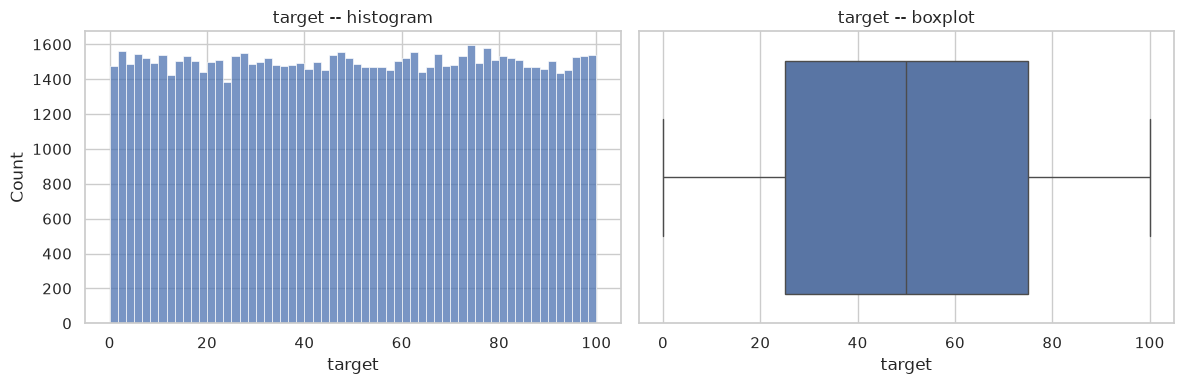

count    90000.000000
mean        50.033981
std         28.897243
min          0.002634
25%         25.091903
50%         50.030705
75%         75.059454
max         99.999482
Name: target, dtype: float64

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["target"], bins=60, ax=ax[0])
ax[0].set_title("target -- histogram")
sns.boxplot(x=df["target"], ax=ax[1])
ax[1].set_title("target -- boxplot")
plt.tight_layout()
plt.show()

df["target"].describe()

Roughly symmetric, mean ~50, no crazy outliers. No transform needed.


## Integer columns


In [6]:
int_cols = df.select_dtypes(include="int64").columns.tolist()
pd.DataFrame({
    "nunique": df[int_cols].nunique(),
    "min": df[int_cols].min(),
    "max": df[int_cols].max(),
})

,nunique,min,max
0,500,0,499
1,500,0,499
2,500,0,499
3,500,0,499
4,500,0,499
5,500,0,499
8,2,0,1
9,500,0,499
10,500,0,499
11,500,0,499


10 of them take exactly 500 distinct values on `[0, 499]` -- look like coordinates, not counts. Column `"8"` is binary.


## Correlation with target


In [7]:
corr = df.corr(numeric_only=True)["target"].drop("target").sort_values(key=np.abs, ascending=False)
corr.head(10)

7     0.012103
40   -0.007216
26    0.006370
39    0.006283
35   -0.006267
1    -0.005545
50   -0.005243
31    0.005077
29   -0.004785
51   -0.004507
Name: target, dtype: float64

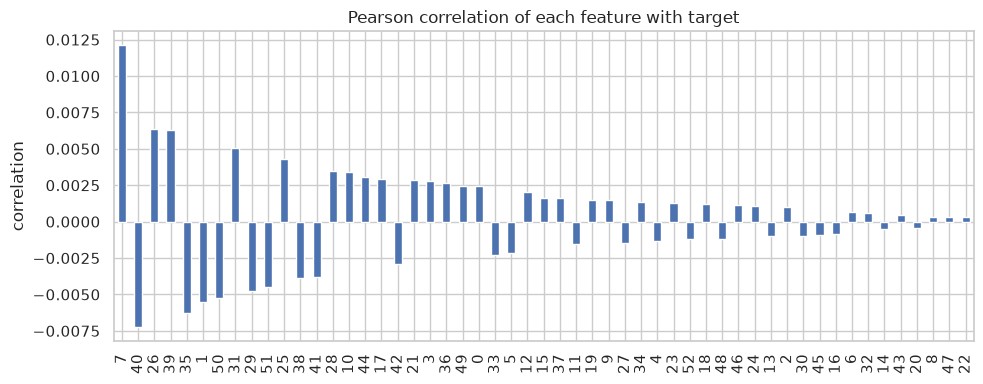

In [8]:
plt.figure(figsize=(10, 4))
corr.plot(kind="bar")
plt.title("Pearson correlation of each feature with target")
plt.ylabel("correlation")
plt.tight_layout()
plt.show()

All 53 features have `|r| < 0.02`. Either there's no signal, or it's something nonlinear that correlation can't catch.


## Feature importance (Random Forest)


In [9]:
X = df.drop(columns="target")
y = df["target"]
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

rf_probe = RandomForestRegressor(n_estimators=150, n_jobs=-1, random_state=42)
rf_probe.fit(X_tr, y_tr)

importance = pd.Series(rf_probe.feature_importances_, index=X.columns).sort_values(ascending=False)
importance.head(10)

6     9.999004e-01
7     9.953058e-05
16    1.180602e-09
45    1.156730e-09
25    1.153614e-09
23    1.152109e-09
14    1.146734e-09
36    1.145981e-09
47    1.145538e-09
10    1.144263e-09
dtype: float64

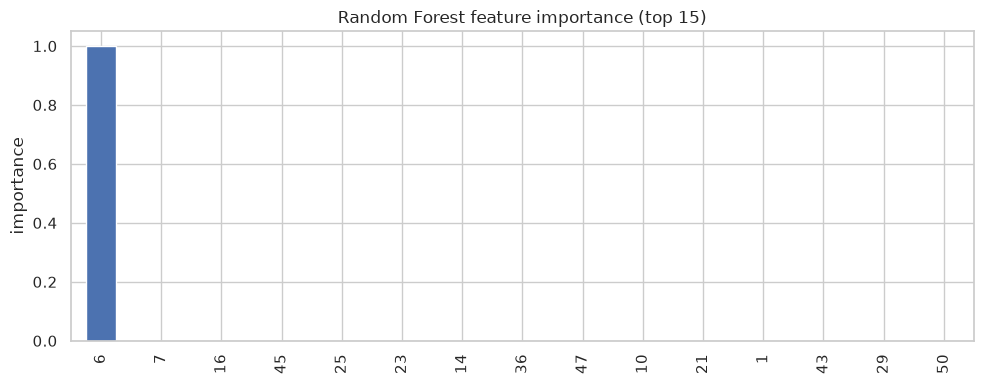

In [10]:
plt.figure(figsize=(10, 4))
importance.head(15).plot(kind="bar")
plt.title("Random Forest feature importance (top 15)")
plt.ylabel("importance")
plt.tight_layout()
plt.show()

Features `"6"` and `"7"` dominate, everything else is noise.


## target vs features 6 and 7


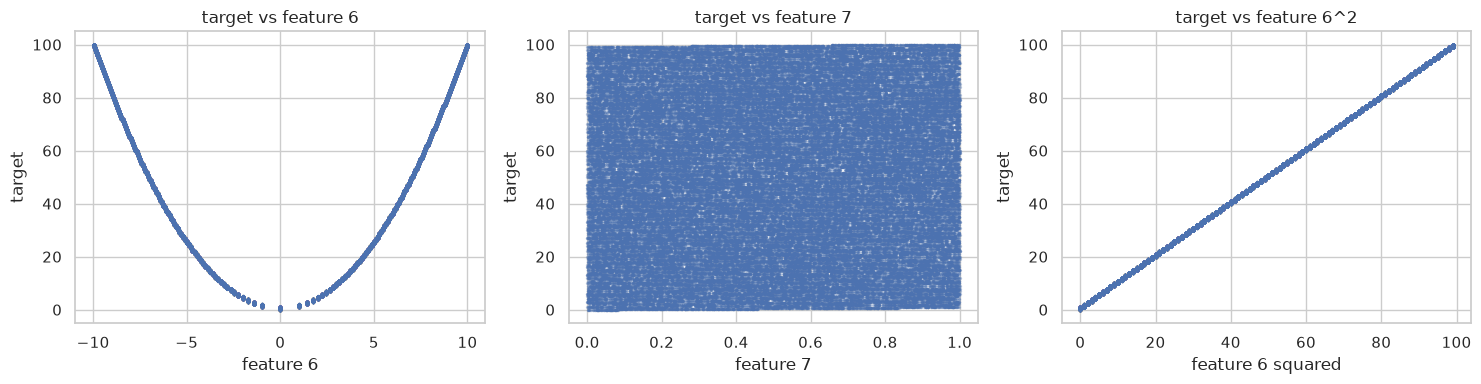

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(df["6"], df["target"], s=2, alpha=0.3)
ax[0].set_xlabel("feature 6"); ax[0].set_ylabel("target"); ax[0].set_title("target vs feature 6")

ax[1].scatter(df["7"], df["target"], s=2, alpha=0.3)
ax[1].set_xlabel("feature 7"); ax[1].set_ylabel("target"); ax[1].set_title("target vs feature 7")

ax[2].scatter(df["6"] ** 2, df["target"], s=2, alpha=0.3)
ax[2].set_xlabel("feature 6 squared"); ax[2].set_ylabel("target"); ax[2].set_title("target vs feature 6^2")

plt.tight_layout()
plt.show()

target vs raw feature 6 is symmetric around 0 (explains the zero correlation). Squaring it gives a straight line -- looks like an exact relationship.


## Checking `target = feature_6**2 + feature_7`


In [12]:
residual = df["target"] - (df["6"] ** 2 + df["7"])
print("max |residual|:", residual.abs().max())
print("mean |residual|:", residual.abs().mean())
print("share of rows within 1e-8:", (residual.abs() < 1e-8).mean())

max |residual|: 5.684341886080802e-14
mean |residual|: 5.482562552098595e-15
share of rows within 1e-8: 1.0


Residual ~1e-14 on all 90k rows, basically float precision, not noise. `target` is exactly `feature_6**2 + feature_7`. The other 51 features are irrelevant.


## Takeaway

Missing `feature_6**2` means linear regression can't see this relationship (RMSE ~29). Add it and it's exact (RMSE ~0) -- RF/LightGBM get close without it too, just not exact.
